In [1]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing
import numpy as np
matrix = np.ones((5,5))
matrix[1:-1,1:-1] = 0
print(matrix)

# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("Means: ")
print(normalized_data.mean(axis=0))

print("\nStandard Deviations:")

print(normalized_data.std(axis=0))

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated coefficients:")
print(theta_hat)
print("\nTrue coefficients:")
print(true_theta)





[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Means: 
[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]

Standard Deviations:
[1. 1. 1.]
Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True coefficients:
[ 2.5 -1.2  3.7]


In [2]:

"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)

# TODO: Display basic information about the dataset
print(df.info())

# TODO: Identify and count missing values
print("\nMissing Values:")
print(df.isnull().sum())

# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)
# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)


# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
avg_scores = df.groupby('major')['exam_score'].mean()
print("Average score by major:")
print(avg_scores)
# TODO: Find the major with the highest average exam_score
best_major = avg_scores.idxmax()
print("\nMajor with highest average score:")
print(best_major)
# TODO: Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print("\nCorrelation:")
print(correlation)
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)

df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0,70,80,90,100],
    labels=[
        'Needs Improvement',
        'Average',
        'Good',
        'Excellent'
    ],
    include_lowest=True
)
print(df[['exam_score','performance']].head())

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
summary = df.groupby(['major','year']).agg(
    num_students=('student_id','count'),
    avg_exam_score=('exam_score','mean'),
    avg_hours_studied=('hours_studied','mean')
)
print(summary)
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top5 = df.nlargest(5, 'exam_score')

cutoff = top5['exam_score'].min()

top_students = df[df['exam_score'] >= cutoff]


# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print("\nPivot Table:")
print(pivot)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing Values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
Average score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Major with highest average score:
CS

Correlation:
-0.0559813834729

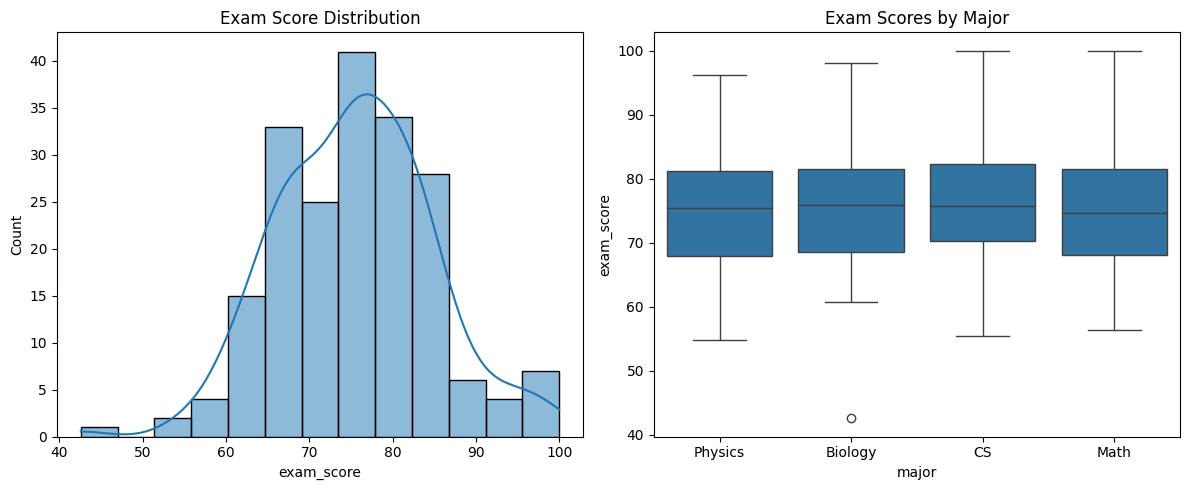

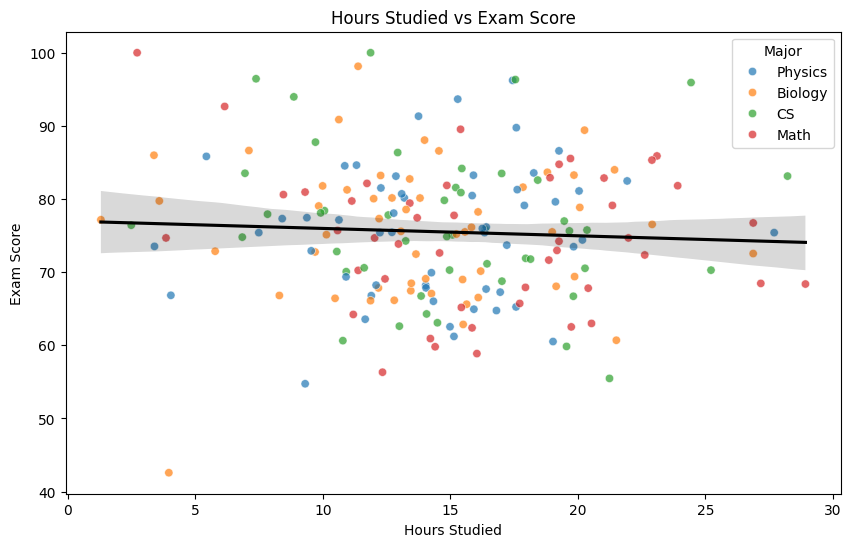

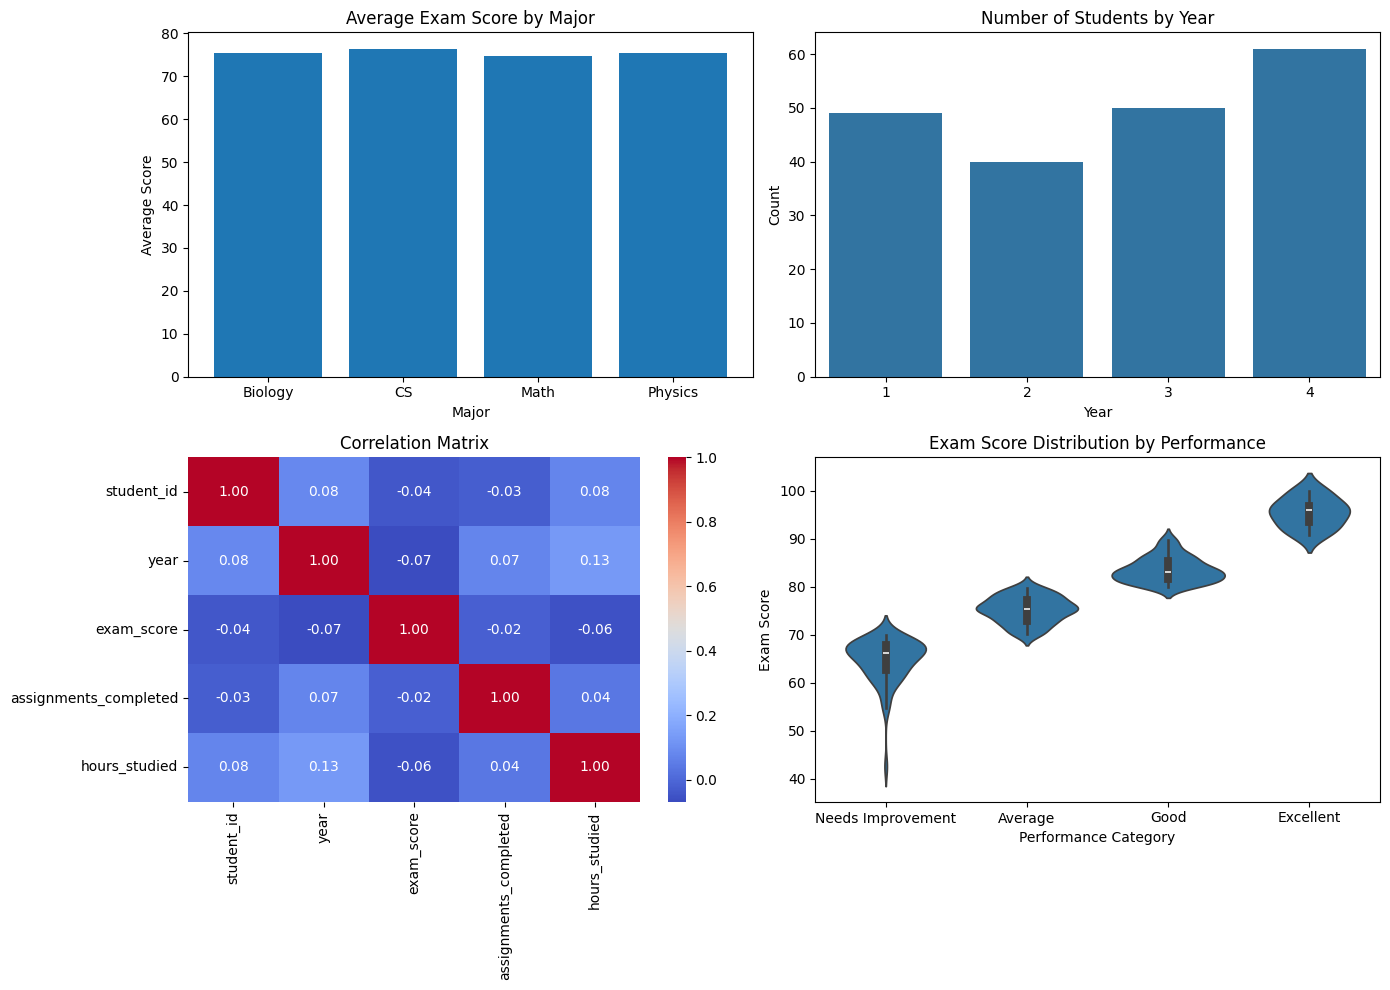

/tmp/ipykernel_8216/2097802691.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = customers.groupby('age_group').agg(


           number_of_customers  average_income  average_clv      total_clv
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683
Top 10% Customers:
    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000

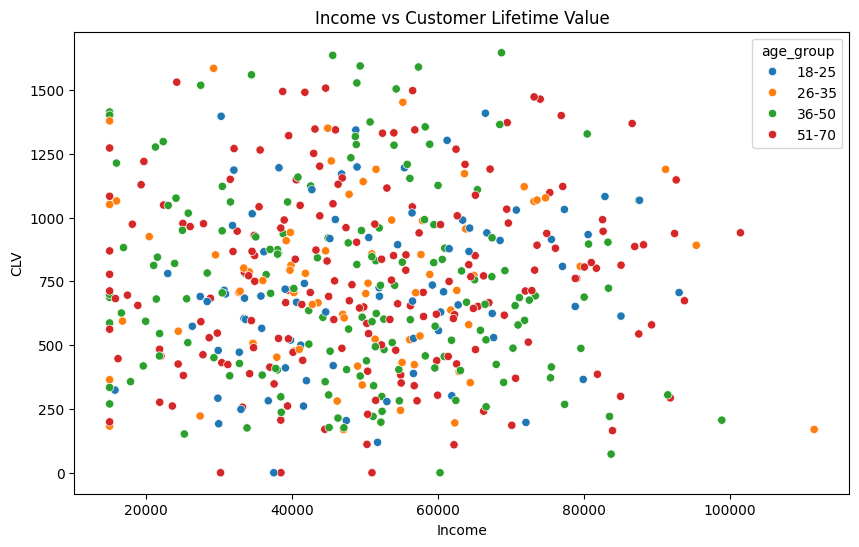

/tmp/ipykernel_8216/2097802691.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_clv = customers.groupby('age_group')['CLV'].mean()


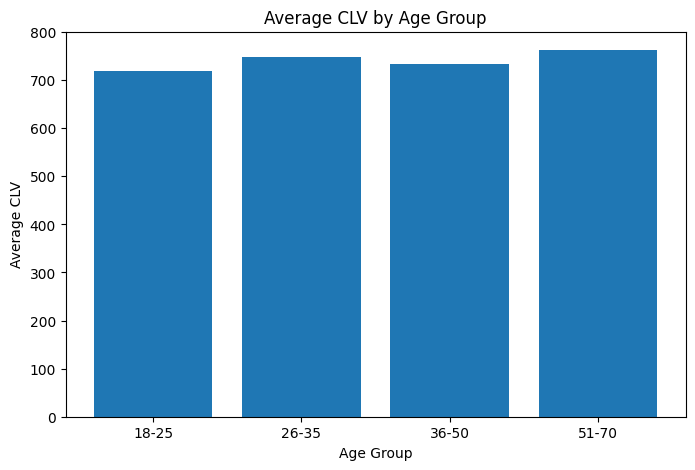

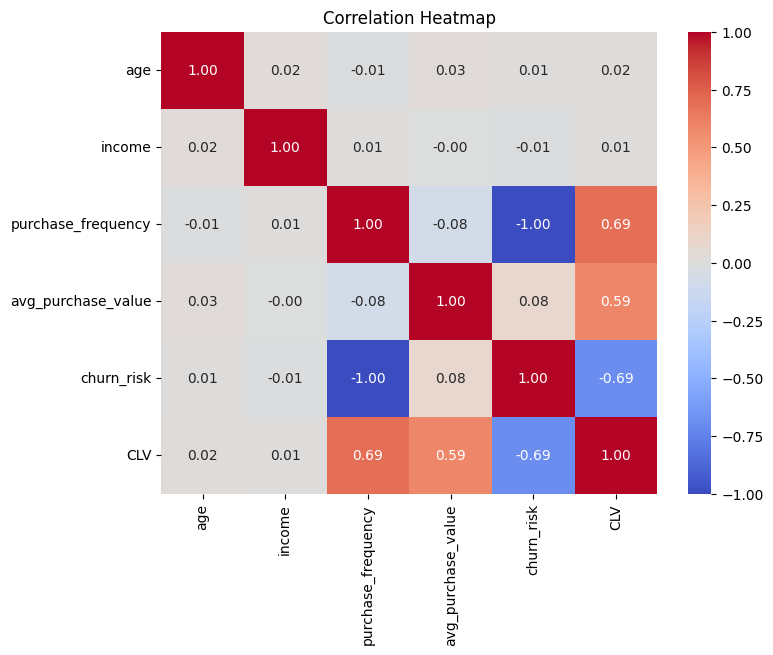

In [ ]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.


# Generate customer data
np.random.seed(42)
n_customers = 500
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
# Calculate churn risk
max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (
    1 - customers['purchase_frequency'] / max_frequency
)

# Calculate CLV
customers['CLV'] = (
    customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk']))

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
summary = customers.groupby('age_group').agg(
    number_of_customers=('age', 'count'),
    average_income=('income', 'mean'),
    average_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)

print(summary)

# TODO: Identify top 10% of customers by CLV
threshold = customers['CLV'].quantile(0.90)

top_customers = customers[
    customers['CLV'] >= threshold
]

print("Top 10% Customers:")
print(top_customers.head())

print("\nNumber of Top Customers:")
print(len(top_customers))

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.show()
#       2. Bar chart of average CLV by age group
avg_clv = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_clv.index, avg_clv.values)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

plt.show()
#       3. Correlation heatmap
plt.figure(figsize=(8, 6))

corr_matrix = customers.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


# TODO: Write a brief analysis paragraph (as a markdown cell)

#       summarizing key findings and recommendations


 Brief analysis of data.
 The data analyzes e-commerce customer behavior and value. It starts by generating synthetic data for 500 fake customers  and providing insights by tracking their age, income, how often they shop, and how much they spend per trip. From there, it calculates how much total money the customers  are worth to the company over time (Customer Lifetime Value, or CLV). It then segments these customers into age brackets  to see which demographic brings in the most cash, isolates the top 10% of customers using CLV, and sets up charts to visually map out trends like whether wealthier people spend more . It cuts off right at the end, but it's essentially trying to build a heatmap to see how all these different customer traits influence each other.